
===== 병합 데이터 =====
        industry     2020     2021     2022  total_energy
0         energy  248.224  260.020  257.502       10920.5
1  manufacturing  144.906  152.932  140.999     5281727.6
2         others   48.277   47.986   48.438     5555667.4


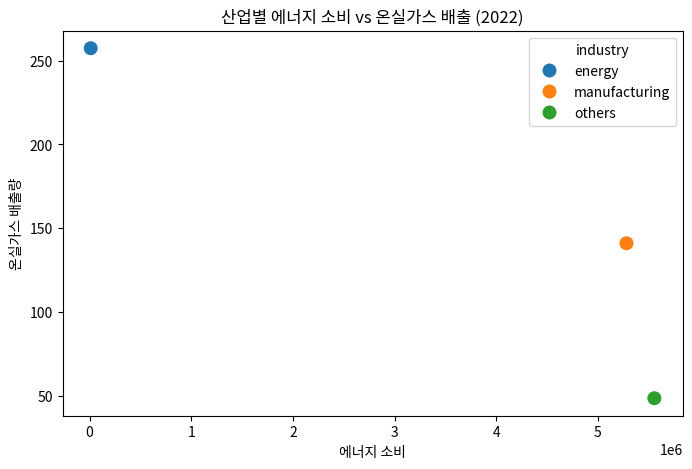

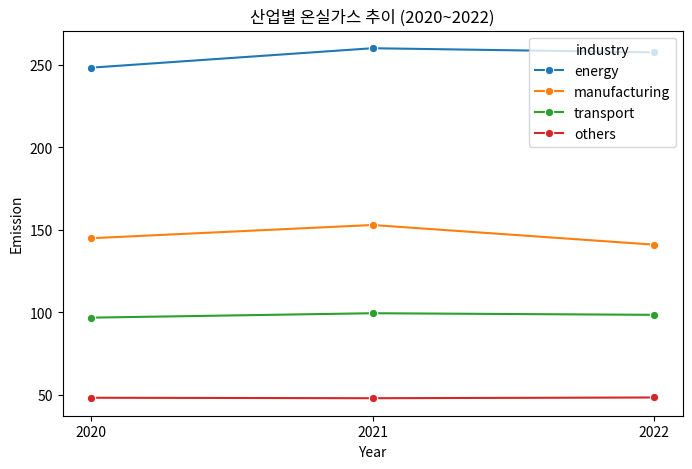

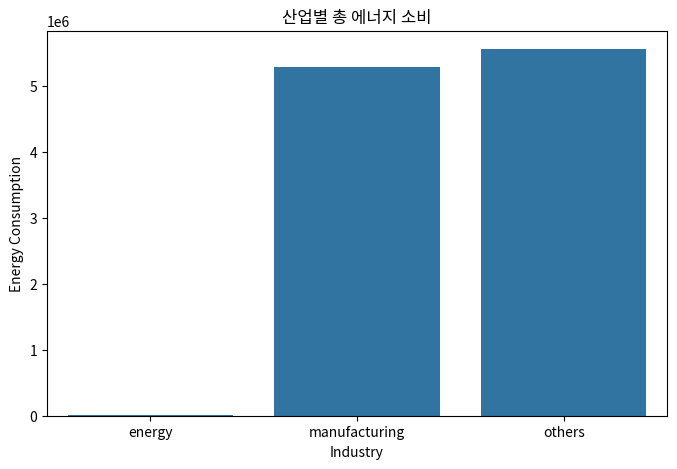


===== 탄소집약도 =====
        industry  carbon_intensity
0         energy          0.023580
1  manufacturing          0.000027
2         others          0.000009


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# =========================
# 1. 데이터 불러오기
# =========================
ghg = pd.read_csv("./data/온실가스_분야별_추이.csv", encoding="cp949")
energy = pd.read_csv("./data/국가에너지수급통계.csv", encoding="cp949")

# =========================
# 2. 온실가스 데이터 전처리
# =========================
ghg_industry = ghg[ghg["구분(2)"] == "A. 연료연소"].copy()

ghg_industry = ghg_industry[
    ghg_industry["구분(3)"].isin([
        "1. 에너지산업",
        "2. 제조업 및 건설업",
        "3. 수송",
        "4. 기타"
    ])
]

ghg_industry = ghg_industry[["구분(3)", "2020", "2021", "2022"]]

ghg_industry = ghg_industry.rename(columns={
    "구분(3)": "industry"
})

ghg_industry["industry"] = ghg_industry["industry"].replace({
    "1. 에너지산업": "energy",
    "2. 제조업 및 건설업": "manufacturing",
    "3. 수송": "transport",
    "4. 기타": "others"
})

# =========================
# 3. 에너지 데이터 전처리
# =========================
energy_industry = energy[
    (energy["에너지흐름별(1)"] == "최종소비") &
    (energy["에너지흐름별(2)"] == "산업")
].copy()

# 세부 업종(에너지흐름별(4))으로 다시 쪼개지지 않은 소계 행만 사용 (중복 합산 방지)
energy_industry = energy_industry[
    energy_industry["에너지흐름별(4)"] == "소계"
]

# 산업 매핑
def map_industry(x):
    if x == "제조업":
        return "manufacturing"
    elif x == "수송":
        return "transport"
    elif x == "건설업":
        return "manufacturing"
    elif x == "농림업":
        return "others"
    elif x == "광업":
        return "energy"
    else:
        return "others"

energy_industry["industry"] = energy_industry["에너지흐름별(3)"].apply(map_industry)

# 에너지 값 컬럼 (숫자 변환)
# "2022.37" 컬럼은 원본 CSV의 숨은 서브헤더 행(0번 행)에서 "총에너지"로 표시된 2022년 총에너지 컬럼입니다.
energy_industry["total_energy"] = pd.to_numeric(
    energy_industry["2022.37"],
    errors="coerce"
)

# 산업별 합계
energy_summary = energy_industry.groupby("industry")["total_energy"].sum().reset_index()

# =========================
# 4. 데이터 병합
# =========================
merged = pd.merge(ghg_industry, energy_summary, on="industry")

print("\n===== 병합 데이터 =====")
print(merged)

# =========================
# 5. 분석 1: 에너지 vs 온실가스 (2022)
# =========================
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=merged,
    x="total_energy",
    y="2022",
    hue="industry",
    s=120
)

plt.title("산업별 에너지 소비 vs 온실가스 배출 (2022)")
plt.xlabel("에너지 소비")
plt.ylabel("온실가스 배출량")
plt.show()

# =========================
# 6. 분석 2: 온실가스 추이
# =========================
ghg_melt = ghg_industry.melt(
    id_vars="industry",
    var_name="year",
    value_name="emission"
)

plt.figure(figsize=(8,5))

sns.lineplot(
    data=ghg_melt,
    x="year",
    y="emission",
    hue="industry",
    marker="o"
)

plt.title("산업별 온실가스 추이 (2020~2022)")
plt.xlabel("Year")
plt.ylabel("Emission")
plt.show()

# =========================
# 7. 분석 3: 에너지 소비 구조
# =========================
plt.figure(figsize=(8,5))

sns.barplot(
    data=energy_summary,
    x="industry",
    y="total_energy"
)

plt.title("산업별 총 에너지 소비")
plt.xlabel("Industry")
plt.ylabel("Energy Consumption")
plt.show()

# =========================
# 8. 분석 4: 탄소집약도
# =========================
merged["carbon_intensity"] = merged["2022"] / merged["total_energy"]

print("\n===== 탄소집약도 =====")
print(merged[["industry", "carbon_intensity"]])